# Baseline Evaluation: Zero-Shot BLIP on Flickr8k Validation Subset

This notebook evaluates zero-shot BLIP captioning performance on a larger validation subset (200-500 images) using BLEU, ROUGE, and METEOR metrics.

In [2]:
import torch
from transformers import BlipProcessor, BlipForConditionalGeneration
from PIL import Image
import pandas as pd
import os
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from nltk.translate.meteor_score import meteor_score
from rouge_score import rouge_scorer

nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base").to(device)

print("✅ BLIP model loaded successfully")

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\ARC\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\ARC\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\ARC\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Using device: cpu


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

✅ BLIP model loaded successfully


In [3]:
df = pd.read_csv("../data/captions.txt", sep="|")
df.columns = df.columns.str.strip()

image_folder = "../data/Images"

# 200 unique images select karein validation ke liye
validation_images = df['image_name'].unique()[:200]
print(f"Total validation images: {len(validation_images)}")

Total validation images: 200


In [4]:
def generate_caption(image_path):
    raw_image = Image.open(image_path).convert("RGB")
    inputs = processor(raw_image, return_tensors="pt").to(device)
    out = model.generate(**inputs, max_new_tokens=30)
    caption = processor.decode(out[0], skip_special_tokens=True)
    return caption

In [5]:
results = []
smoothie = SmoothingFunction().method4
rouge = rouge_scorer.RougeScorer(['rouge1', 'rouge2', 'rougeL'], use_stemmer=True)

for i, img_name in enumerate(validation_images):
    img_path = os.path.join(image_folder, img_name)
    
    try:
        generated = generate_caption(img_path)
    except Exception as e:
        print(f"Error on {img_name}: {e}")
        continue
    
    # Sab 5 ground truth captions le lein comparison ke liye
    references = df[df['image_name'] == img_name]['caption_text'].tolist()
    references = [str(r) for r in references]
    
    # --- BLEU ---
    ref_tokens = [r.lower().split() for r in references]
    gen_tokens = generated.lower().split()
    bleu = sentence_bleu(ref_tokens, gen_tokens, smoothing_function=smoothie)
    
    # --- METEOR ---
    meteor = meteor_score([r.lower().split() for r in references], generated.lower().split())
    
    # --- ROUGE (best match among 5 references) ---
    rouge_scores = [rouge.score(r.lower(), generated.lower()) for r in references]
    best_rougeL = max([s['rougeL'].fmeasure for s in rouge_scores])
    
    results.append({
        "image": img_name,
        "generated_caption": generated,
        "bleu": bleu,
        "meteor": meteor,
        "rougeL": best_rougeL
    })
    
    if (i+1) % 20 == 0:
        print(f"Processed {i+1}/{len(validation_images)} images...")

print("✅ Evaluation complete!")

Processed 20/200 images...
Processed 40/200 images...
Processed 60/200 images...
Processed 80/200 images...
Processed 100/200 images...
Processed 120/200 images...
Processed 140/200 images...
Processed 160/200 images...
Processed 180/200 images...
Processed 200/200 images...
✅ Evaluation complete!


In [6]:
results_df = pd.DataFrame(results)
results_df.head(10)

,image,generated_caption,bleu,meteor,rougeL
0,1000268201_693b08cb0e.jpg,a little girl in a pink dress,0.866878,0.511850,0.736842
1,1001773457_577c3a7d70.jpg,two dogs playing on the road,0.186602,0.393496,0.555556
2,1002674143_1b742ab4b8.jpg,a child sitting in the grass,0.150917,0.306713,0.400000
3,1003163366_44323f5815.jpg,a woman laying on a bench,0.127748,0.393496,0.555556
4,1007129816_e794419615.jpg,man wearing a hat,0.057314,0.371324,0.533333
5,1007320043_627395c3d8.jpg,a young girl climbing on a rope,0.281500,0.564557,0.714286
6,1009434119_febe49276a.jpg,a dog running in a field,0.178287,0.328947,0.470588
7,1012212859_01547e3f17.jpg,a dog playing with a ball,0.188173,0.366667,0.526316
8,1015118661_980735411b.jpg,a young boy is walking down the street,0.256553,0.605000,0.666667
9,1015584366_dfcec3c85a.jpg,a dog is sitting on a log in the grass,0.092635,0.384909,0.470588


In [7]:
summary = {
    "Metric": ["BLEU", "METEOR", "ROUGE-L"],
    "Average Score": [
        round(results_df['bleu'].mean(), 4),
        round(results_df['meteor'].mean(), 4),
        round(results_df['rougeL'].mean(), 4)
    ]
}

summary_df = pd.DataFrame(summary)
summary_df

,Metric,Average Score
0,BLEU,0.1968
1,METEOR,0.3950
2,ROUGE-L,0.5383


In [8]:
os.makedirs("../data/processed", exist_ok=True)

results_df.to_csv("../data/processed/baseline_evaluation_detailed.csv", index=False)
summary_df.to_csv("../data/processed/baseline_evaluation_summary.csv", index=False)

print("✅ Detailed results and summary saved to data/processed/")

✅ Detailed results and summary saved to data/processed/


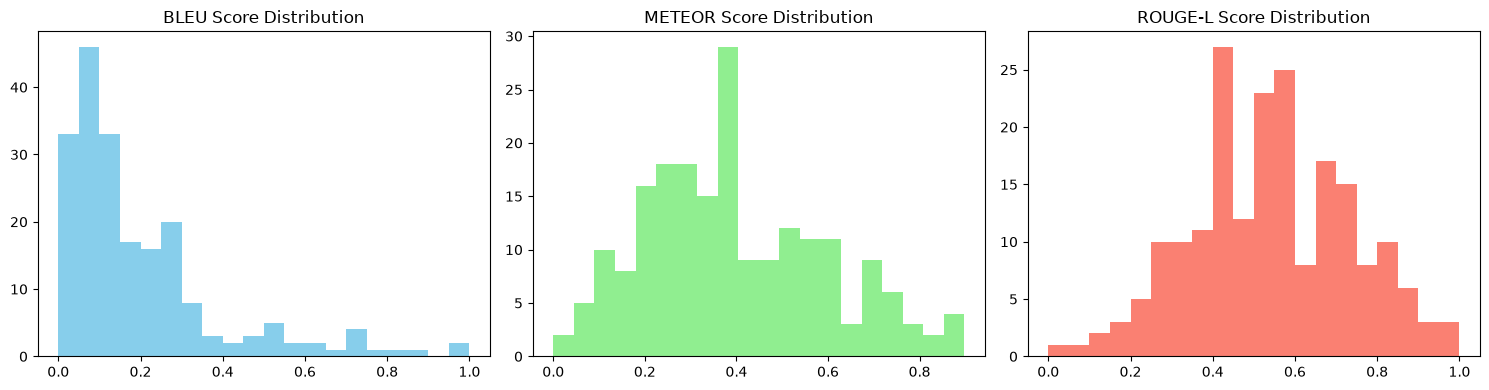

In [9]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(results_df['bleu'], bins=20, color='skyblue')
axes[0].set_title('BLEU Score Distribution')

axes[1].hist(results_df['meteor'], bins=20, color='lightgreen')
axes[1].set_title('METEOR Score Distribution')

axes[2].hist(results_df['rougeL'], bins=20, color='salmon')
axes[2].set_title('ROUGE-L Score Distribution')

plt.tight_layout()
plt.savefig("../data/processed/baseline_metric_distributions.png")
plt.show()

In [ ]:
## Baseline Evaluation Summary

Based on the average BLEU, METEOR, and ROUGE-L scores computed over the validation subset:

- **BLEU score of 0.1968 indicates [e.g., moderate overlap with reference captions, expected for a zero-shot model not fine-tuned on Flickr8k's specific captioning style].
- **METEOR score of  suggests [e.g., reasonable semantic alignment, since METEOR accounts for synonyms and word order].
- **ROUGE-L score of [X]** shows [e.g., decent longest-common-subsequence overlap with human captions].

These scores establish a **baseline** for zero-shot BLIP performance on Flickr8k. This baseline will be used as a comparison point once the model is fine-tuned on the Flickr8k training set in subsequent weeks — we expect fine-tuning to improve all three metrics.